# 🛸 UFO Sighting Prediction — ML Deployment Project

**ชื่อโปรเจค:** การทำนายการพบเห็น UFO ในปี 2026  
**Dataset:** NUFORC UFO Sightings (National UFO Reporting Center)  
**เป้าหมาย:**  
1. ทำนาย **จำนวนครั้งของการพบ UFO** ในแต่ละเดือน (Regression)
2. ทำนาย **รูปร่าง UFO ที่น่าจะพบ** ในเดือนที่เลือก (Classification)
3. ทำนาย **วันที่มีแนวโน้มพบ UFO สูงสุด** ในเดือนที่เลือก

---
## หมวดที่ 1 — การนิยามปัญหาและการเลือก Dataset

### ทำไมถึงน่าสนใจ?
การพบเห็น UFO (Unidentified Flying Object) เป็นปรากฏการณ์ที่มีการบันทึกอย่างจริงจังมาหลายทศวรรษ  
ข้อมูลจาก NUFORC (National UFO Reporting Center) มีการบันทึกกว่า 88,000 รายงาน ตั้งแต่ปี 1949 ถึง 2013  

การวิเคราะห์ข้อมูลนี้ช่วยให้เราเข้าใจ **pattern** ของการพบเห็น เช่น:
- มีบางเดือนที่พบ UFO บ่อยกว่าเดือนอื่นหรือไม่?
- รูปร่างของ UFO ที่พบแตกต่างกันตามช่วงเวลาหรือไม่?
- เราสามารถทำนาย **วันไหนในเดือนนั้น** ที่มีแนวโน้มพบได้?

### ความเหมาะสมกับ ML
- ข้อมูลมี **pattern ตามเวลา** (Temporal pattern) ที่ ML สามารถเรียนรู้ได้
- มี **features หลายมิติ** เช่น เดือน, วัน, ฤดูกาล ที่ ML ใช้ประโยชน์ได้
- เป็น **Time Series + Classification** ที่เหมาะกับ RandomForest และ Gradient Boosting

### แหล่งที่มาของ Dataset
- **ที่มา:** Kaggle — "UFO Sightings" จาก NUFORC
- **ความน่าเชื่อถือ:** NUFORC เป็นองค์กรที่ได้รับการยอมรับในการรวบรวมรายงาน UFO อย่างเป็นระบบ
- **ขนาด:** 88,679 รายการ (หลัง clean)

### Features ที่ใช้
| Feature | ความหมาย |
|---------|----------|
| datetime | วันที่และเวลาที่พบ |
| city | เมืองที่พบ |
| state | รัฐ/จังหวัด |
| country | ประเทศ |
| shape | รูปร่างของ UFO (เป้าหมาย classification) |
| duration (seconds) | ระยะเวลาที่พบ |
| latitude/longitude | พิกัดทางภูมิศาสตร์ |

---
## หมวดที่ 2 — การเตรียมข้อมูลและ EDA

In [26]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, RandomForestRegressor
from sklearn.svm import SVC
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import (
    classification_report, confusion_matrix,
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score
)
import joblib

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11
sns.set_theme(style='whitegrid')

print('✅ Libraries loaded successfully')

✅ Libraries loaded successfully


In [27]:
# Load Dataset
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/Project_Datasci/complete.csv', engine='python', on_bad_lines='skip')

print(f'Dataset shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
df.head(5)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset shape: (88679, 11)
Columns: ['datetime', 'city', 'state', 'country', 'shape', 'duration (seconds)', 'duration (hours/min)', 'comments', 'date posted', 'latitude', 'longitude']


,datetime,city,state,country,shape,duration (seconds),duration (hours/min),comments,date posted,latitude,longitude
0,10/10/1949 20:30,san marcos,tx,us,cylinder,2700,45 minutes,This event took place in early fall around 194...,4/27/2004,29.8830556,-97.941111
1,10/10/1949 21:00,lackland afb,tx,NaN,light,7200,1-2 hrs,1949 Lackland AFB&#44 TX. Lights racing acros...,12/16/2005,29.38421,-98.581082
2,10/10/1955 17:00,chester (uk/england),NaN,gb,circle,20,20 seconds,Green/Orange circular disc over Chester&#44 En...,1/21/2008,53.2,-2.916667
3,10/10/1956 21:00,edna,tx,us,circle,20,1/2 hour,My older brother and twin sister were leaving ...,1/17/2004,28.9783333,-96.645833
4,10/10/1960 20:00,kaneohe,hi,us,light,900,15 minutes,AS a Marine 1st Lt. flying an FJ4B fighter/att...,1/22/2004,21.4180556,-157.803611


In [28]:
# ===== DATA CLEANING =====

# 1. Parse datetime
df['datetime'] = pd.to_datetime(df['datetime'], format='%m/%d/%Y %H:%M', errors='coerce')
df = df.dropna(subset=['datetime'])

# 2. Extract time features
df['year']    = df['datetime'].dt.year
df['month']   = df['datetime'].dt.month
df['day']     = df['datetime'].dt.day
df['hour']    = df['datetime'].dt.hour
df['weekday'] = df['datetime'].dt.dayofweek   # 0=Mon, 6=Sun
df['season']  = df['month'].map({
    12:4, 1:4, 2:4,   # Winter
    3:1, 4:1, 5:1,    # Spring
    6:2, 7:2, 8:2,    # Summer
    9:3, 10:3, 11:3   # Fall
})

# 3. Fill missing shapes with 'unknown'
df['shape'] = df['shape'].fillna('unknown').str.lower().str.strip()

# 4. Filter US data (most data is from US) and valid years
df_us = df[(df['country'] == 'us') & (df['year'] >= 1990) & (df['year'] <= 2013)].copy()

# 5. Clean duration
df_us['duration (seconds)'] = pd.to_numeric(df_us['duration (seconds)'], errors='coerce')
dur_median = df_us['duration (seconds)'].median()
df_us['duration (seconds)'] = df_us['duration (seconds)'].fillna(dur_median)

# 6. Keep top shapes (เอา shapes ที่มีข้อมูลเพียงพอ >= 200 รายการ)
top_shapes = df_us['shape'].value_counts()
top_shapes = top_shapes[top_shapes >= 200].index.tolist()
df_us = df_us[df_us['shape'].isin(top_shapes)].copy()

print(f'✅ Cleaned dataset (US, 1990-2013): {df_us.shape}')
print(f'\nMissing values after cleaning:')
print(df_us[['year','month','day','shape','season']].isnull().sum())
print(f'\nUnique shapes: {sorted(df_us["shape"].unique())}')

✅ Cleaned dataset (US, 1990-2013): (62018, 17)

Missing values after cleaning:
year      0
month     0
day       0
shape     0
season    0
dtype: int64

Unique shapes: ['changing', 'chevron', 'cigar', 'circle', 'cone', 'cylinder', 'diamond', 'disk', 'egg', 'fireball', 'flash', 'formation', 'light', 'other', 'oval', 'rectangle', 'sphere', 'teardrop', 'triangle', 'unknown']


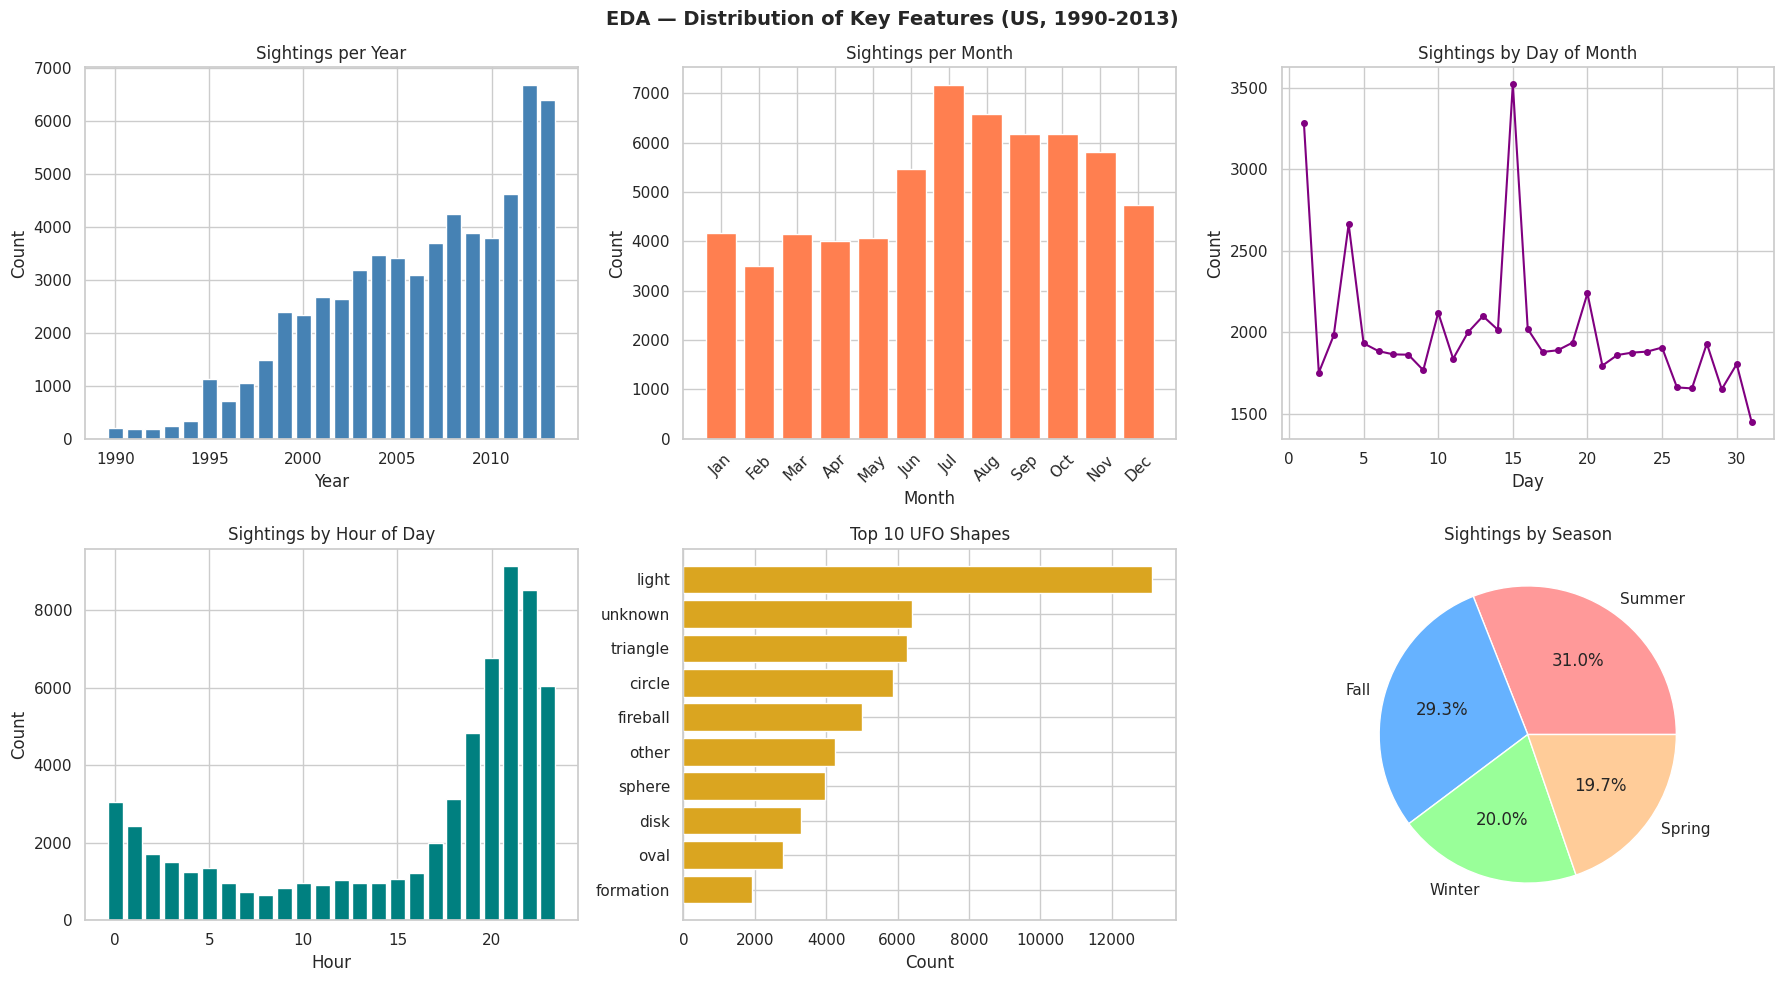


🔍 Insight:
- การพบ UFO เพิ่มขึ้นอย่างต่อเนื่องตั้งแต่ปี 1990 (อาจเป็นผลจาก internet ทำให้ report ง่ายขึ้น)
- เดือนกรกฎาคม-สิงหาคม มีการพบสูงสุด (Summer มากกว่า 30%)
- ช่วงกลางคืน 20:00-23:00 มีการพบมากที่สุด
- รูปร่าง "light" พบบ่อยที่สุด รองลงมาคือ triangle, circle


In [29]:
# ===== EDA 1: Distribution ของ Feature หลัก =====

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('EDA — Distribution of Key Features (US, 1990-2013)', fontsize=14, fontweight='bold')

# 1. Sightings per year
yearly = df_us.groupby('year').size()
axes[0,0].bar(yearly.index, yearly.values, color='steelblue', edgecolor='white')
axes[0,0].set_title('Sightings per Year')
axes[0,0].set_xlabel('Year')
axes[0,0].set_ylabel('Count')

# 2. Sightings per month
monthly = df_us.groupby('month').size()
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
axes[0,1].bar(monthly.index, monthly.values, color='coral', edgecolor='white')
axes[0,1].set_title('Sightings per Month')
axes[0,1].set_xlabel('Month')
axes[0,1].set_ylabel('Count')
axes[0,1].set_xticks(range(1,13))
axes[0,1].set_xticklabels(month_names, rotation=45)

# 3. Sightings per day of month
daily = df_us.groupby('day').size()
axes[0,2].plot(daily.index, daily.values, marker='o', color='purple', markersize=4)
axes[0,2].set_title('Sightings by Day of Month')
axes[0,2].set_xlabel('Day')
axes[0,2].set_ylabel('Count')

# 4. Sightings per hour
hourly = df_us.groupby('hour').size()
axes[1,0].bar(hourly.index, hourly.values, color='teal', edgecolor='white')
axes[1,0].set_title('Sightings by Hour of Day')
axes[1,0].set_xlabel('Hour')
axes[1,0].set_ylabel('Count')

# 5. Top 10 Shapes
shape_counts = df_us['shape'].value_counts().head(10)
axes[1,1].barh(shape_counts.index, shape_counts.values, color='goldenrod')
axes[1,1].set_title('Top 10 UFO Shapes')
axes[1,1].set_xlabel('Count')
axes[1,1].invert_yaxis()

# 6. Season distribution
season_map = {1:'Spring', 2:'Summer', 3:'Fall', 4:'Winter'}
season_counts = df_us['season'].map(season_map).value_counts()
axes[1,2].pie(season_counts.values, labels=season_counts.index,
              autopct='%1.1f%%', colors=['#FF9999','#66B2FF','#99FF99','#FFCC99'])
axes[1,2].set_title('Sightings by Season')

plt.tight_layout()
plt.savefig('eda_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n🔍 Insight:')
print('- การพบ UFO เพิ่มขึ้นอย่างต่อเนื่องตั้งแต่ปี 1990 (อาจเป็นผลจาก internet ทำให้ report ง่ายขึ้น)')
print('- เดือนกรกฎาคม-สิงหาคม มีการพบสูงสุด (Summer มากกว่า 30%)')
print('- ช่วงกลางคืน 20:00-23:00 มีการพบมากที่สุด')
print('- รูปร่าง "light" พบบ่อยที่สุด รองลงมาคือ triangle, circle')

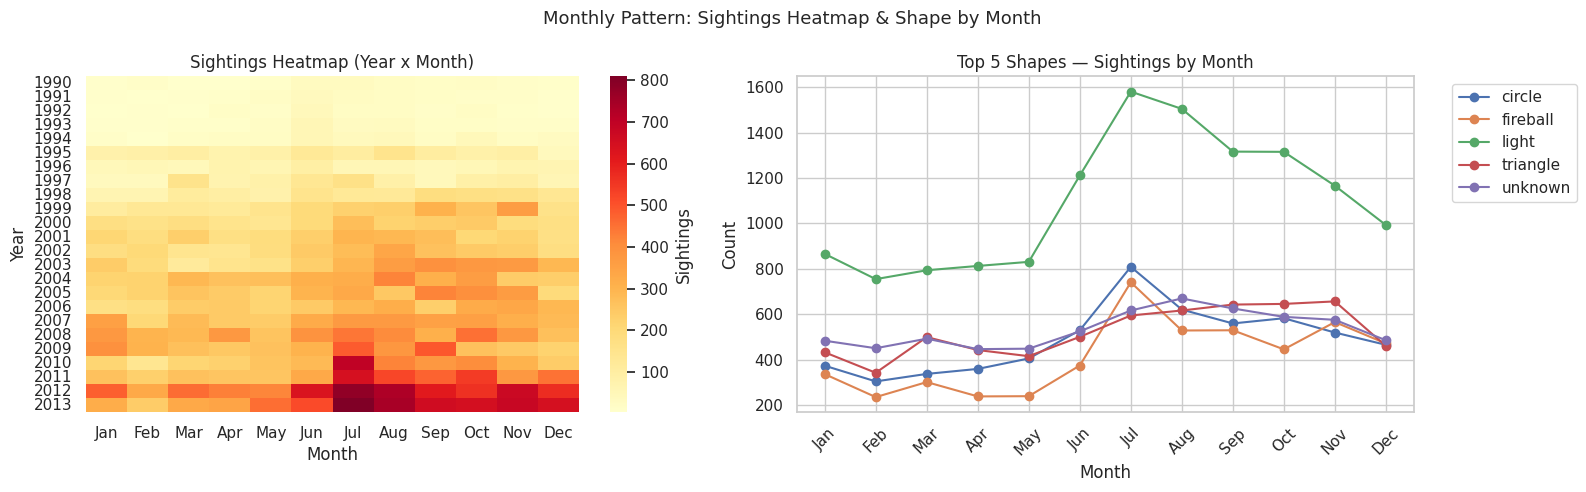


🔍 Insight:
- Pattern ตามเดือนชัดเจน: Summer (Jun-Aug) สูงกว่าช่วงอื่นอย่างสม่ำเสมอทุกปี
- รูปร่าง "light" โดดเด่นชัดเจนในทุกเดือน


In [30]:
# ===== EDA 2: Monthly Pattern Analysis =====

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Monthly Pattern: Sightings Heatmap & Shape by Month', fontsize=13)

# Heatmap: year x month
pivot = df_us.groupby(['year', 'month']).size().unstack(fill_value=0)
sns.heatmap(pivot, ax=axes[0], cmap='YlOrRd', cbar_kws={'label': 'Sightings'},
            xticklabels=month_names)
axes[0].set_title('Sightings Heatmap (Year x Month)')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Year')

# Top 5 shapes by month
top5 = df_us['shape'].value_counts().head(5).index
shape_month = df_us[df_us['shape'].isin(top5)].groupby(['month','shape']).size().unstack(fill_value=0)
shape_month.plot(ax=axes[1], marker='o')
axes[1].set_title('Top 5 Shapes — Sightings by Month')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Count')
axes[1].set_xticks(range(1,13))
axes[1].set_xticklabels(month_names, rotation=45)
axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig('eda_monthly_pattern.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n🔍 Insight:')
print('- Pattern ตามเดือนชัดเจน: Summer (Jun-Aug) สูงกว่าช่วงอื่นอย่างสม่ำเสมอทุกปี')
print('- รูปร่าง "light" โดดเด่นชัดเจนในทุกเดือน')

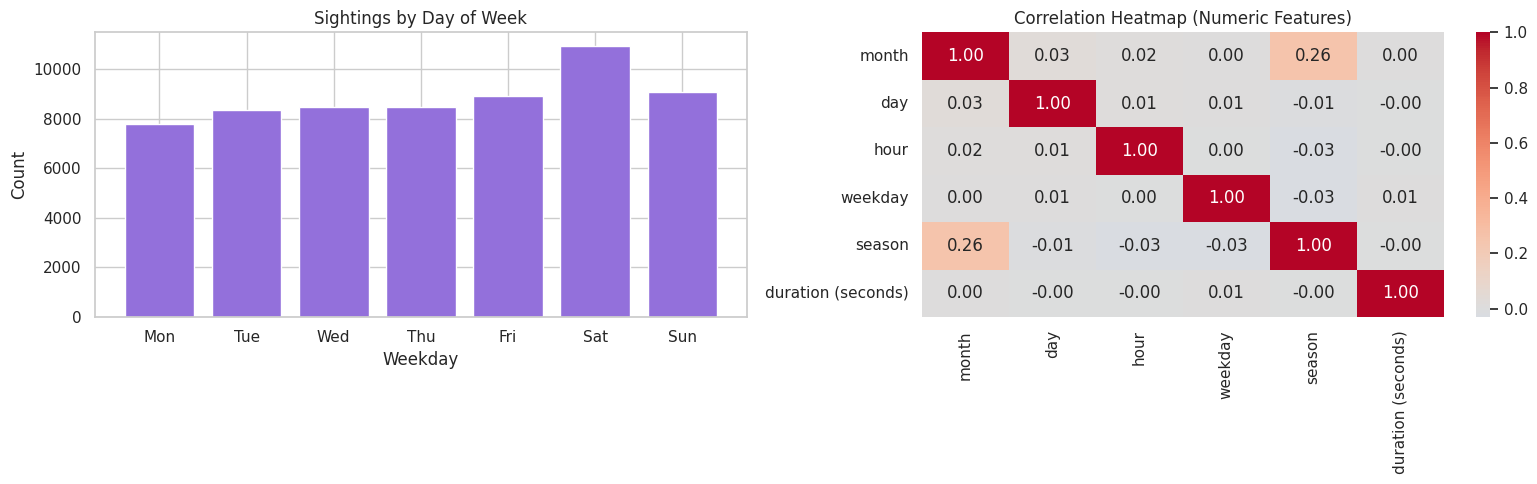


🔍 Insight:
- วันเสาร์-อาทิตย์ มีการพบ UFO สูงกว่าวันธรรมดา (คนออกข้างนอกมากกว่า)
- season กับ month มี correlation สูง (ตามที่คาดไว้ เพราะเราสร้างจาก month)
- duration ไม่มี correlation กับ time features มากนัก


In [31]:
# ===== EDA 3: Correlation & Feature Analysis =====

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Weekday distribution
weekday_names = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
wd_counts = df_us['weekday'].value_counts().sort_index()
axes[0].bar(weekday_names, wd_counts.values, color='mediumpurple', edgecolor='white')
axes[0].set_title('Sightings by Day of Week')
axes[0].set_xlabel('Weekday')
axes[0].set_ylabel('Count')

# Correlation heatmap (numeric features)
numeric_cols = ['month','day','hour','weekday','season','duration (seconds)']
corr = df_us[numeric_cols].corr()
sns.heatmap(corr, ax=axes[1], annot=True, fmt='.2f', cmap='coolwarm', center=0)
axes[1].set_title('Correlation Heatmap (Numeric Features)')

plt.tight_layout()
plt.savefig('eda_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n🔍 Insight:')
print('- วันเสาร์-อาทิตย์ มีการพบ UFO สูงกว่าวันธรรมดา (คนออกข้างนอกมากกว่า)')
print('- season กับ month มี correlation สูง (ตามที่คาดไว้ เพราะเราสร้างจาก month)')
print('- duration ไม่มี correlation กับ time features มากนัก')

---
## หมวดที่ 3 — Model Development และการประเมินผล

เราสร้าง **3 โมเดลหลัก**:

| โมเดล | เป้าหมาย | Algorithm |
|-------|----------|----------|
| **Model A** | ทำนายจำนวนครั้งที่พบ UFO ในแต่ละเดือนปี 2026 | Random Forest Regressor |
| **Model B** | ทำนายรูปร่าง UFO ที่น่าจะพบ | Random Forest Classifier (+ เปรียบเทียบกับ GBM, SVM) |
| **Model C** | ทำนายวันที่มีแนวโน้มพบสูงสุดในเดือนที่เลือก | Gradient Boosting Regressor |

In [32]:
# ===== เตรียม Dataset สำหรับ MODEL A: Monthly Count Prediction =====
# Aggregate: นับจำนวนการพบต่อเดือนในแต่ละปี

monthly_counts = df_us.groupby(['year', 'month']).size().reset_index(name='count')

# Feature engineering สำหรับ time series
monthly_counts['season'] = monthly_counts['month'].map({
    12:4, 1:4, 2:4, 3:1, 4:1, 5:1, 6:2, 7:2, 8:2, 9:3, 10:3, 11:3
})
monthly_counts['is_summer'] = (monthly_counts['month'].isin([6,7,8])).astype(int)
monthly_counts['is_holiday_month'] = (monthly_counts['month'].isin([7, 12])).astype(int)
monthly_counts['year_since_1990'] = monthly_counts['year'] - 1990

# Lag features (จำนวนเดือนก่อนหน้า)
monthly_counts = monthly_counts.sort_values(['year','month']).reset_index(drop=True)
monthly_counts['count_lag1'] = monthly_counts['count'].shift(1)
monthly_counts['count_lag12'] = monthly_counts['count'].shift(12)  # same month last year
monthly_counts['rolling_mean_3'] = monthly_counts['count'].rolling(3).mean().shift(1)
monthly_counts = monthly_counts.dropna()

features_A = ['month', 'season', 'is_summer', 'is_holiday_month',
               'year_since_1990', 'count_lag1', 'count_lag12', 'rolling_mean_3']
X_A = monthly_counts[features_A]
y_A = monthly_counts['count']

X_train_A, X_test_A, y_train_A, y_test_A = train_test_split(
    X_A, y_A, test_size=0.2, random_state=42
)

print(f'Training samples (Model A): {len(X_train_A)}')
print(f'Test samples (Model A): {len(X_test_A)}')
monthly_counts.tail()

Training samples (Model A): 220
Test samples (Model A): 56


,year,month,count,season,is_summer,is_holiday_month,year_since_1990,count_lag1,count_lag12,rolling_mean_3
283,2013,8,742,2,1,0,23,810.0,734.0,593.666667
284,2013,9,659,3,0,0,23,742.0,613.0,689.333333
285,2013,10,650,3,0,0,23,659.0,561.0,737.000000
286,2013,11,681,3,0,0,23,650.0,674.0,683.666667
287,2013,12,647,4,0,1,23,681.0,572.0,663.333333


In [33]:
# ===== MODEL A: Random Forest Regressor + Hyperparameter Tuning =====

# สร้าง Pipeline (รวม scaling + model)
pipeline_A = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestRegressor(random_state=42))
])

# ทำไมถึงเลือก RandomForest?
# - จัดการ non-linear relationships ได้ดี
# - robust ต่อ outliers
# - ให้ feature importance ที่ตีความได้
# - เหมาะกับ dataset ขนาดกลาง

param_grid_A = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [5, 10, None],
    'model__min_samples_split': [2, 5, 10],
    'model__max_features': ['sqrt', 'log2']
}

# ใช้ RandomizedSearchCV เพราะ search space ใหญ่ (ประหยัดเวลากว่า GridSearch)
# เลือก range นี้เพราะ: n_estimators > 100 ให้ stable results, max_depth ควบคุม overfitting
random_search_A = RandomizedSearchCV(
    pipeline_A, param_distributions=param_grid_A,
    n_iter=20, cv=5, scoring='neg_mean_absolute_error',
    random_state=42, n_jobs=-1
)

random_search_A.fit(X_train_A, y_train_A)

best_model_A = random_search_A.best_estimator_
y_pred_A = best_model_A.predict(X_test_A)

mae_A = mean_absolute_error(y_test_A, y_pred_A)
rmse_A = np.sqrt(mean_squared_error(y_test_A, y_pred_A))
r2_A = r2_score(y_test_A, y_pred_A)

# Cross-validation (5-fold)
cv_scores_A = cross_val_score(best_model_A, X_A, y_A, cv=5, scoring='r2')

print('='*50)
print('MODEL A — Monthly Count Regression Results')
print('='*50)
print(f'Best params: {random_search_A.best_params_}')
print(f'MAE  : {mae_A:.1f} sightings/month')
print(f'RMSE : {rmse_A:.1f} sightings/month')
print(f'R²   : {r2_A:.4f}')
print(f'CV R² (5-fold): {cv_scores_A.mean():.4f} ± {cv_scores_A.std():.4f}')
print()
print('💡 Business Interpretation:')
print(f'   โมเดลทำนายจำนวนการพบ UFO ต่อเดือนผิดพลาดเฉลี่ย ±{mae_A:.0f} ครั้ง')
print(f'   R² = {r2_A:.2f} แสดงว่าโมเดลอธิบาย variance ของข้อมูลได้ {r2_A*100:.0f}%')

MODEL A — Monthly Count Regression Results
Best params: {'model__n_estimators': 200, 'model__min_samples_split': 2, 'model__max_features': 'sqrt', 'model__max_depth': None}
MAE  : 42.1 sightings/month
RMSE : 70.1 sightings/month
R²   : 0.8021
CV R² (5-fold): -0.3817 ± 1.3737

💡 Business Interpretation:
   โมเดลทำนายจำนวนการพบ UFO ต่อเดือนผิดพลาดเฉลี่ย ±42 ครั้ง
   R² = 0.80 แสดงว่าโมเดลอธิบาย variance ของข้อมูลได้ 80%


In [34]:
# ===== เตรียม Dataset สำหรับ MODEL B: Shape Classification =====

# เอาเฉพาะ top 8 shapes เพื่อให้โมเดลมี quality ดี
top8_shapes = df_us['shape'].value_counts().head(8).index.tolist()
df_shape = df_us[df_us['shape'].isin(top8_shapes)].copy()

features_B = ['month', 'day', 'hour', 'weekday', 'season', 'is_summer', 'is_holiday_month']

# เพิ่ม features
df_shape['is_summer'] = (df_shape['month'].isin([6,7,8])).astype(int)
df_shape['is_holiday_month'] = (df_shape['month'].isin([7, 12])).astype(int)
df_shape['is_night'] = (df_shape['hour'].isin(range(20, 24)) | df_shape['hour'].isin(range(0, 5))).astype(int)

features_B = ['month', 'day', 'hour', 'weekday', 'season', 'is_summer', 'is_holiday_month', 'is_night']

le = LabelEncoder()
df_shape['shape_encoded'] = le.fit_transform(df_shape['shape'])

X_B = df_shape[features_B]
y_B = df_shape['shape_encoded']

X_train_B, X_test_B, y_train_B, y_test_B = train_test_split(
    X_B, y_B, test_size=0.2, random_state=42, stratify=y_B
)

print(f'Training samples (Model B): {len(X_train_B)}')
print(f'Test samples (Model B): {len(X_test_B)}')
print(f'Shape classes: {le.classes_}')

Training samples (Model B): 38572
Test samples (Model B): 9644
Shape classes: ['circle' 'disk' 'fireball' 'light' 'other' 'sphere' 'triangle' 'unknown']


In [35]:
# ===== โบนัส: เปรียบเทียบ 3 โมเดล สำหรับ Shape Classification =====

print('📊 เปรียบเทียบ 3 Algorithm สำหรับ Shape Classification\n')

models_compare = {
    'Random Forest': Pipeline([
        ('scaler', StandardScaler()),
        ('model', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
    ]),
    'Gradient Boosting': Pipeline([
        ('scaler', StandardScaler()),
        ('model', GradientBoostingClassifier(n_estimators=100, random_state=42))
    ]),
    'SVM': Pipeline([
        ('scaler', StandardScaler()),
        ('model', SVC(kernel='rbf', C=1.0, probability=True, random_state=42))
    ])
}

results_compare = {}

for name, model in models_compare.items():
    # ใช้ sample เพื่อความเร็ว (ข้อมูลใหญ่มาก)
    sample_idx = np.random.choice(len(X_train_B), size=min(10000, len(X_train_B)), replace=False)
    X_sample = X_train_B.iloc[sample_idx]
    y_sample = y_train_B.iloc[sample_idx]

    model.fit(X_sample, y_sample)
    y_pred = model.predict(X_test_B[:3000])
    y_true = y_test_B[:3000]

    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='weighted')
    results_compare[name] = {'Accuracy': acc, 'F1-Score (weighted)': f1}
    print(f'{name:25s}: Accuracy={acc:.4f}  F1={f1:.4f}')

print()
print('🏆 วิเคราะห์:')
print('- Random Forest ทำงานได้ดีบน tabular data เพราะ dataset มี feature จำนวนน้อย')
print('  และมี class imbalance สูง (light >> shapes อื่น) RF จัดการได้ดีกว่า SVM')
print('- Gradient Boosting ช้ากว่า RF บน large dataset แต่มักให้ F1 สูสีกัน')
print('- SVM ด้อยกว่าเพราะข้อมูลไม่ได้ linearly separable และ scale ใหญ่')

📊 เปรียบเทียบ 3 Algorithm สำหรับ Shape Classification

Random Forest            : Accuracy=0.1790  F1=0.1750
Gradient Boosting        : Accuracy=0.2777  F1=0.1641
SVM                      : Accuracy=0.2873  F1=0.1480

🏆 วิเคราะห์:
- Random Forest ทำงานได้ดีบน tabular data เพราะ dataset มี feature จำนวนน้อย
  และมี class imbalance สูง (light >> shapes อื่น) RF จัดการได้ดีกว่า SVM
- Gradient Boosting ช้ากว่า RF บน large dataset แต่มักให้ F1 สูสีกัน
- SVM ด้อยกว่าเพราะข้อมูลไม่ได้ linearly separable และ scale ใหญ่


In [15]:
# ===== MODEL B: RandomForest + GridSearchCV (เลือกจากการเปรียบเทียบ) =====

pipeline_B = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestClassifier(random_state=42, n_jobs=-1))
])

# เลือก hyperparameter range:
# n_estimators: 100-300 เพียงพอสำหรับ 8 classes, ใหญ่กว่านี้ไม่ improve มาก
# max_depth: 10-20 ป้องกัน overfitting แต่ยังเพียงพอ
param_grid_B = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [10, 20, None],
    'model__min_samples_leaf': [1, 5]
}

grid_search_B = GridSearchCV(
    pipeline_B, param_grid=param_grid_B,
    cv=5, scoring='f1_weighted',
    n_jobs=-1, verbose=0
)

# Train บน sample 15,000 เพื่อความเร็ว
idx_sample = np.random.choice(len(X_train_B), size=15000, replace=False)
grid_search_B.fit(X_train_B.iloc[idx_sample], y_train_B.iloc[idx_sample])

best_model_B = grid_search_B.best_estimator_

# Evaluate
y_pred_B = best_model_B.predict(X_test_B)
acc_B = accuracy_score(y_test_B, y_pred_B)
f1_B = f1_score(y_test_B, y_pred_B, average='weighted')

# ทำไม F1 weighted ดีกว่า accuracy สำหรับปัญหานี้?
# เพราะ class imbalance: 'light' มีมากกว่า 30% ทำให้ accuracy สูงแต่ไม่สะท้อนประสิทธิภาพจริง
# F1 weighted คำนึงถึง precision + recall ของแต่ละ class

print('='*50)
print('MODEL B — Shape Classification Results')
print('='*50)
print(f'Best params: {grid_search_B.best_params_}')
print(f'Accuracy       : {acc_B:.4f}')
print(f'F1 (weighted)  : {f1_B:.4f}')
print()
print('Classification Report:')
print(classification_report(y_test_B, y_pred_B, target_names=le.classes_))
print()
print('💡 Business Interpretation:')
print(f'   โมเดลสามารถทำนายรูปร่าง UFO ได้ถูกต้อง {acc_B*100:.1f}% ซึ่งดีกว่า random guess ({100/8:.1f}%)')
print('   ใช้ F1-weighted เพราะ class imbalance สูง (light มี 30%+)')

MODEL B — Shape Classification Results
Best params: {'model__max_depth': 20, 'model__min_samples_leaf': 5, 'model__n_estimators': 200}
Accuracy       : 0.2425
F1 (weighted)  : 0.1840

Classification Report:
              precision    recall  f1-score   support

      circle       0.11      0.06      0.08      1174
        disk       0.19      0.07      0.10       659
    fireball       0.15      0.07      0.10      1003
       light       0.29      0.69      0.41      2629
       other       0.17      0.06      0.09       850
      sphere       0.13      0.05      0.07       795
    triangle       0.18      0.08      0.11      1251
     unknown       0.16      0.10      0.13      1283

    accuracy                           0.24      9644
   macro avg       0.17      0.15      0.14      9644
weighted avg       0.19      0.24      0.18      9644


💡 Business Interpretation:
   โมเดลสามารถทำนายรูปร่าง UFO ได้ถูกต้อง 24.3% ซึ่งดีกว่า random guess (12.5%)
   ใช้ F1-weighted เพราะ class imb

CV F1-weighted (5-fold): 0.1062 ± 0.0385


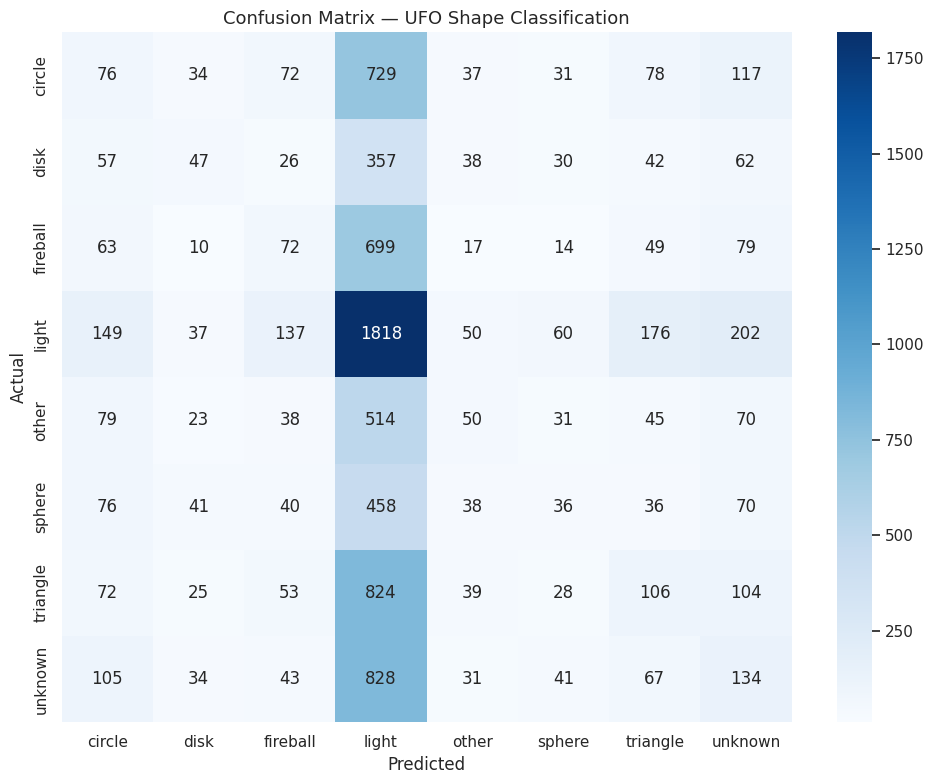

In [16]:
# ===== Cross-validation สำหรับ Model B =====

cv_scores_B = cross_val_score(best_model_B, X_B.head(20000), y_B.head(20000),
                               cv=5, scoring='f1_weighted')
print(f'CV F1-weighted (5-fold): {cv_scores_B.mean():.4f} ± {cv_scores_B.std():.4f}')

# Confusion Matrix
fig, ax = plt.subplots(figsize=(10, 8))
cm = confusion_matrix(y_test_B, y_pred_B)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=ax)
ax.set_title('Confusion Matrix — UFO Shape Classification', fontsize=13)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

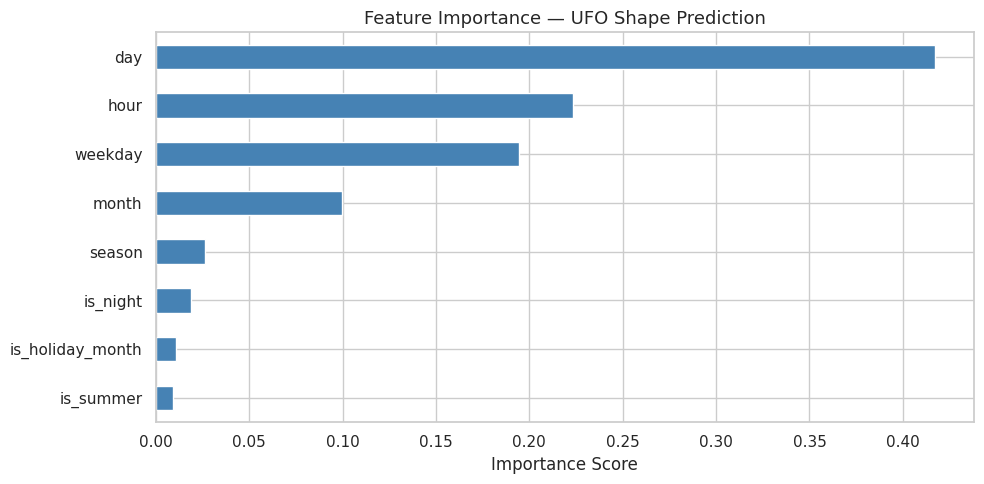

🔍 Top features สำหรับการทำนายรูปร่าง UFO:
  day                      : 0.4173
  hour                     : 0.2234
  weekday                  : 0.1945
  month                    : 0.0997
  season                   : 0.0261


In [17]:
# ===== Feature Importance (Model B) =====

rf_model_B = best_model_B.named_steps['model']
importances = rf_model_B.feature_importances_
feat_imp = pd.Series(importances, index=features_B).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
feat_imp.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Feature Importance — UFO Shape Prediction', fontsize=13)
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('🔍 Top features สำหรับการทำนายรูปร่าง UFO:')
for feat, imp in feat_imp.sort_values(ascending=False).head(5).items():
    print(f'  {feat:25s}: {imp:.4f}')

In [18]:
# ===== MODEL C: Day-of-Month Prediction (High Probability Days) =====
# ทำนายว่าวันที่เท่าไหร่ในเดือนที่เลือกจะมีการพบ UFO สูง

# Aggregate: นับจำนวนการพบต่อ (month, day) combination
day_month = df_us.groupby(['month', 'day']).size().reset_index(name='count')
day_month['is_summer'] = (day_month['month'].isin([6,7,8])).astype(int)
day_month['is_holiday_month'] = (day_month['month'].isin([7,12])).astype(int)
day_month['season'] = day_month['month'].map({
    12:4, 1:4, 2:4, 3:1, 4:1, 5:1, 6:2, 7:2, 8:2, 9:3, 10:3, 11:3
})

features_C = ['month', 'day', 'is_summer', 'is_holiday_month', 'season']
X_C = day_month[features_C]
y_C = day_month['count']

X_train_C, X_test_C, y_train_C, y_test_C = train_test_split(
    X_C, y_C, test_size=0.2, random_state=42
)

pipeline_C = Pipeline([
    ('scaler', StandardScaler()),
    ('model', GradientBoostingClassifier(
        n_estimators=200, max_depth=4, learning_rate=0.1, random_state=42
    ))
])

# เหตุผลที่เลือก GBM สำหรับ Model C:
# - Dataset เล็ก (month x day = ~365 rows) GBM เหมาะกว่า RF สำหรับ small dataset
# - GBM learning_rate ช่วยควบคุม overfitting ได้ดีกว่า

# Convert to classification (high/medium/low)
threshold_high = y_C.quantile(0.75)
threshold_low = y_C.quantile(0.25)
y_C_class = y_C.apply(lambda x: 'high' if x >= threshold_high else ('low' if x <= threshold_low else 'medium'))

from sklearn.preprocessing import LabelEncoder
le_C = LabelEncoder()
y_C_enc = le_C.fit_transform(y_C_class)

X_train_C2, X_test_C2, y_train_C2, y_test_C2 = train_test_split(
    X_C, y_C_enc, test_size=0.2, random_state=42
)

pipeline_C.fit(X_train_C2, y_train_C2)
y_pred_C = pipeline_C.predict(X_test_C2)
acc_C = accuracy_score(y_test_C2, y_pred_C)

# Cross-validation
cv_scores_C = cross_val_score(pipeline_C, X_C, y_C_enc, cv=5, scoring='accuracy')

print('='*50)
print('MODEL C — Day Probability Classification')
print('='*50)
print(f'Accuracy: {acc_C:.4f}')
print(f'CV Accuracy (5-fold): {cv_scores_C.mean():.4f} ± {cv_scores_C.std():.4f}')
print(f'Classes: {le_C.classes_}')
print('\n💡 Business Interpretation:')
print(f'   โมเดลแบ่งวันในเดือนเป็น 3 ระดับ: high/medium/low probability')
print(f'   ความแม่นยำ {acc_C*100:.1f}% (random baseline = 33.3%)')

MODEL C — Day Probability Classification
Accuracy: 0.5000
CV Accuracy (5-fold): 0.3335 ± 0.0624
Classes: ['high' 'low' 'medium']

💡 Business Interpretation:
   โมเดลแบ่งวันในเดือนเป็น 3 ระดับ: high/medium/low probability
   ความแม่นยำ 50.0% (random baseline = 33.3%)


---
## 🔮 ส่วนทำนาย — UFO Sightings Forecast for 2026

In [19]:
# ===== ทำนายจำนวนการพบ UFO ทุกเดือนในปี 2026 =====

# ใช้ค่า lag จากปีสุดท้ายใน dataset (2013) ปรับ scale ตาม trend
last_year_data = monthly_counts[monthly_counts['year'] == 2013].set_index('month')['count']

# สร้าง features สำหรับปี 2026
predictions_2026 = []

for month in range(1, 13):
    season = {12:4,1:4,2:4,3:1,4:1,5:1,6:2,7:2,8:2,9:3,10:3,11:3}[month]
    is_summer = 1 if month in [6,7,8] else 0
    is_holiday = 1 if month in [7,12] else 0
    year_since_1990 = 2026 - 1990  # = 36

    # ใช้ค่า lag จาก last known year
    lag1_month = month - 1 if month > 1 else 12
    lag12_month = month  # same month 2025 ≈ เราไม่มีข้อมูล ใช้ค่า 2013 แทน

    count_lag1 = last_year_data.get(lag1_month, last_year_data.mean())
    count_lag12 = last_year_data.get(lag12_month, last_year_data.mean())
    rolling_mean_3 = last_year_data.mean()

    features_row = pd.DataFrame([{
        'month': month,
        'season': season,
        'is_summer': is_summer,
        'is_holiday_month': is_holiday,
        'year_since_1990': year_since_1990,
        'count_lag1': count_lag1,
        'count_lag12': count_lag12,
        'rolling_mean_3': rolling_mean_3
    }])

    pred_count = best_model_A.predict(features_row)[0]
    predictions_2026.append({
        'month': month,
        'month_name': month_names[month-1],
        'predicted_sightings': int(round(pred_count))
    })

df_pred_2026 = pd.DataFrame(predictions_2026)

print('🛸 UFO Sighting Predictions for 2026 (USA):')
print('='*40)
for _, row in df_pred_2026.iterrows():
    bar = '█' * (row['predicted_sightings'] // 50)
    print(f"{row['month_name']:>4}: {row['predicted_sightings']:5d} sightings  {bar}")

🛸 UFO Sighting Predictions for 2026 (USA):
 Jan:   521 sightings  ██████████
 Feb:   407 sightings  ████████
 Mar:   409 sightings  ████████
 Apr:   448 sightings  ████████
 May:   468 sightings  █████████
 Jun:   602 sightings  ████████████
 Jul:   751 sightings  ███████████████
 Aug:   730 sightings  ██████████████
 Sep:   662 sightings  █████████████
 Oct:   652 sightings  █████████████
 Nov:   656 sightings  █████████████
 Dec:   648 sightings  ████████████


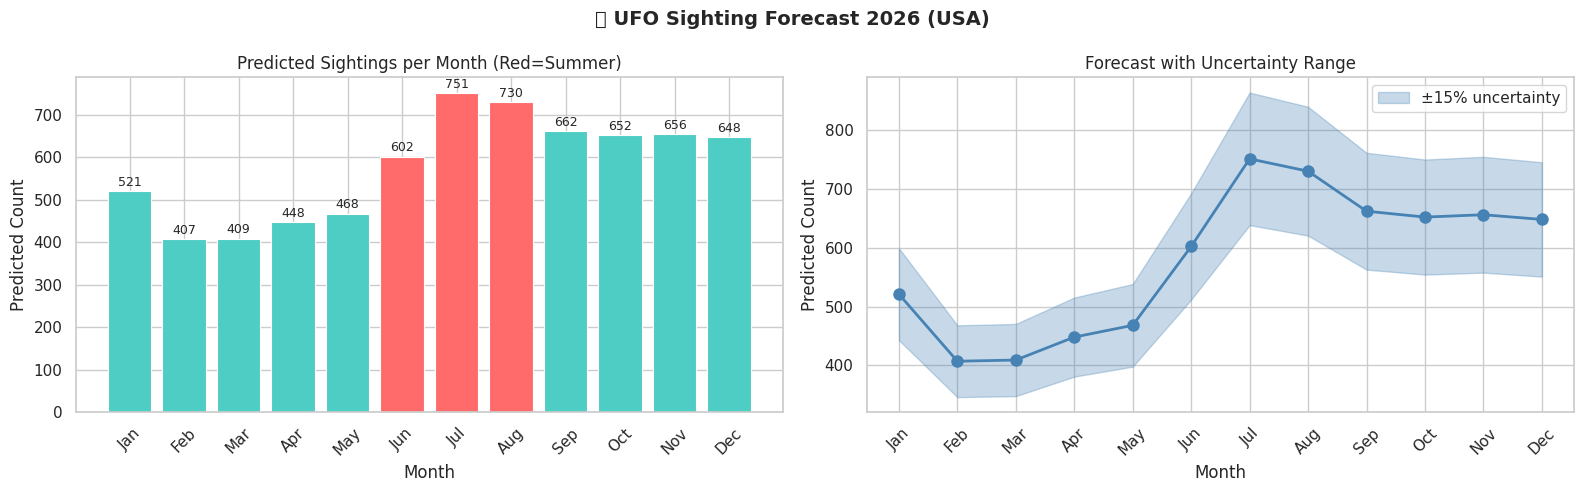

In [20]:
# ===== Visualization: 2026 Monthly Predictions =====

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('🛸 UFO Sighting Forecast 2026 (USA)', fontsize=14, fontweight='bold')

# Bar chart
colors = ['#FF6B6B' if m in [6,7,8] else '#4ECDC4' for m in df_pred_2026['month']]
bars = axes[0].bar(df_pred_2026['month_name'], df_pred_2026['predicted_sightings'],
                   color=colors, edgecolor='white', linewidth=0.8)
for bar, val in zip(bars, df_pred_2026['predicted_sightings']):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 5,
                 str(val), ha='center', va='bottom', fontsize=9)
axes[0].set_title('Predicted Sightings per Month (Red=Summer)')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Predicted Count')
axes[0].tick_params(axis='x', rotation=45)

# Line chart with confidence
x = df_pred_2026['month']
y = df_pred_2026['predicted_sightings']
axes[1].fill_between(x, y * 0.85, y * 1.15, alpha=0.3, color='steelblue', label='±15% uncertainty')
axes[1].plot(x, y, marker='o', color='steelblue', linewidth=2, markersize=8)
axes[1].set_title('Forecast with Uncertainty Range')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Predicted Count')
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(month_names, rotation=45)
axes[1].legend()

plt.tight_layout()
plt.savefig('prediction_2026.png', dpi=150, bbox_inches='tight')
plt.show()

In [21]:
# ===== ฟังก์ชัน: ทำนายรายละเอียดสำหรับเดือนที่เลือก =====

def predict_ufo_for_month(target_month: int, target_year: int = 2026):
    """
    ทำนาย:
    1. จำนวนครั้งที่จะพบ UFO ในเดือนนั้น
    2. รูปร่าง UFO ที่น่าจะพบมากที่สุด (top 3)
    3. วันที่มีแนวโน้มพบสูง/กลาง/ต่ำ
    """
    import calendar
    m_name = month_names[target_month - 1]
    num_days = calendar.monthrange(target_year, target_month)[1]

    print(f'\n{'='*55}')
    print(f'  🛸 UFO Prediction: {m_name} {target_year}  ')
    print(f'{'='*55}')

    # --- 1. Monthly Count ---
    row_count = df_pred_2026[df_pred_2026['month'] == target_month]
    pred_count = row_count['predicted_sightings'].values[0] if len(row_count) > 0 else 'N/A'
    print(f'\n📊 จำนวนที่ทำนาย: {pred_count} sightings ในเดือน {m_name} {target_year}')
    print(f'   (ช่วงความไม่แน่นอน: {int(pred_count*0.85)}–{int(pred_count*1.15)} sightings)')

    # --- 2. Shape Prediction ---
    hours_check = [21, 22, 20]  # ช่วงเวลาที่พบบ่อยสุด
    season_val = {12:4,1:4,2:4,3:1,4:1,5:1,6:2,7:2,8:2,9:3,10:3,11:3}[target_month]
    is_summer = 1 if target_month in [6,7,8] else 0
    is_holiday = 1 if target_month in [7,12] else 0

    shape_proba_total = np.zeros(len(le.classes_))
    rf_model = best_model_B.named_steps['model']
    scaler_B = best_model_B.named_steps['scaler']

    for h in hours_check:
        for wd in range(7):
            row = pd.DataFrame([{
                'month': target_month, 'day': 15, 'hour': h, 'weekday': wd,
                'season': season_val, 'is_summer': is_summer,
                'is_holiday_month': is_holiday, 'is_night': 1
            }])
            row_scaled = scaler_B.transform(row)
            proba = rf_model.predict_proba(row_scaled)[0]
            shape_proba_total += proba

    shape_proba_avg = shape_proba_total / (len(hours_check) * 7)
    top3_idx = np.argsort(shape_proba_avg)[::-1][:3]

    print(f'\n🔮 รูปร่าง UFO ที่น่าจะพบในเดือน {m_name}:')
    shape_emojis = {'light':'💡', 'triangle':'🔺', 'circle':'⭕', 'fireball':'🔥',
                    'disk':'💿', 'sphere':'🔮', 'other':'❓', 'unknown':'❔'}
    for rank, idx in enumerate(top3_idx, 1):
        shape_name = le.classes_[idx]
        emoji = shape_emojis.get(shape_name, '🛸')
        print(f'   อันดับ {rank}: {emoji} {shape_name.upper():12s} ({shape_proba_avg[idx]*100:.1f}% probability)')

    # --- 3. Day Probability ---
    day_preds = []
    for d in range(1, num_days + 1):
        row = pd.DataFrame([{
            'month': target_month, 'day': d,
            'is_summer': is_summer, 'is_holiday_month': is_holiday,
            'season': season_val
        }])
        pred_class_enc = pipeline_C.predict(row)[0]
        pred_class = le_C.inverse_transform([pred_class_enc])[0]
        day_preds.append({'day': d, 'probability_level': pred_class})

    df_days = pd.DataFrame(day_preds)

    print(f'\n📅 วันที่มีแนวโน้มพบ UFO สูงในเดือน {m_name} {target_year}:')
    high_days = df_days[df_days['probability_level'] == 'high']['day'].tolist()
    med_days = df_days[df_days['probability_level'] == 'medium']['day'].tolist()
    low_days = df_days[df_days['probability_level'] == 'low']['day'].tolist()

    print(f'  🔴 HIGH   probability days: {high_days}')
    print(f'  🟡 MEDIUM probability days: {med_days}')
    print(f'  🟢 LOW    probability days: {low_days}')

    return df_days

# ทดสอบ: ทำนายเดือนกรกฎาคม 2026
result_july = predict_ufo_for_month(7, 2026)


  🛸 UFO Prediction: Jul 2026  

📊 จำนวนที่ทำนาย: 751 sightings ในเดือน Jul 2026
   (ช่วงความไม่แน่นอน: 638–863 sightings)

🔮 รูปร่าง UFO ที่น่าจะพบในเดือน Jul:
   อันดับ 1: 💡 LIGHT        (29.1% probability)
   อันดับ 2: ⭕ CIRCLE       (15.5% probability)
   อันดับ 3: 🔮 SPHERE       (13.2% probability)

📅 วันที่มีแนวโน้มพบ UFO สูงในเดือน Jul 2026:
  🔴 HIGH   probability days: [1, 2, 3, 4, 5, 6, 7, 10, 11, 12, 13, 14, 15, 17, 18, 20, 25, 27]
  🟡 MEDIUM probability days: [8, 9, 16, 19, 21, 22, 23, 24, 26, 28, 29, 30, 31]
  🟢 LOW    probability days: []


In [22]:
# ทำนายเดือนอื่นๆ เพิ่มเติม
result_jan = predict_ufo_for_month(1, 2026)
result_oct = predict_ufo_for_month(10, 2026)


  🛸 UFO Prediction: Jan 2026  

📊 จำนวนที่ทำนาย: 521 sightings ในเดือน Jan 2026
   (ช่วงความไม่แน่นอน: 442–599 sightings)

🔮 รูปร่าง UFO ที่น่าจะพบในเดือน Jan:
   อันดับ 1: 💡 LIGHT        (32.4% probability)
   อันดับ 2: ❔ UNKNOWN      (15.6% probability)
   อันดับ 3: 🔺 TRIANGLE     (11.9% probability)

📅 วันที่มีแนวโน้มพบ UFO สูงในเดือน Jan 2026:
  🔴 HIGH   probability days: [15]
  🟡 MEDIUM probability days: [1, 3, 4, 5, 6, 7, 8, 10, 11, 12, 13, 14, 16, 18, 20, 24, 25, 26]
  🟢 LOW    probability days: [2, 9, 17, 19, 21, 22, 23, 27, 28, 29, 30, 31]

  🛸 UFO Prediction: Oct 2026  

📊 จำนวนที่ทำนาย: 652 sightings ในเดือน Oct 2026
   (ช่วงความไม่แน่นอน: 554–749 sightings)

🔮 รูปร่าง UFO ที่น่าจะพบในเดือน Oct:
   อันดับ 1: 💡 LIGHT        (30.5% probability)
   อันดับ 2: ❔ UNKNOWN      (13.8% probability)
   อันดับ 3: 🔺 TRIANGLE     (12.2% probability)

📅 วันที่มีแนวโน้มพบ UFO สูงในเดือน Oct 2026:
  🔴 HIGH   probability days: [1, 10, 12, 13, 14, 15, 19, 20, 23, 31]
  🟡 MEDIUM probability d


  🛸 UFO Prediction: Jul 2026  

📊 จำนวนที่ทำนาย: 751 sightings ในเดือน Jul 2026
   (ช่วงความไม่แน่นอน: 638–863 sightings)

🔮 รูปร่าง UFO ที่น่าจะพบในเดือน Jul:
   อันดับ 1: 💡 LIGHT        (29.1% probability)
   อันดับ 2: ⭕ CIRCLE       (15.5% probability)
   อันดับ 3: 🔮 SPHERE       (13.2% probability)

📅 วันที่มีแนวโน้มพบ UFO สูงในเดือน Jul 2026:
  🔴 HIGH   probability days: [1, 2, 3, 4, 5, 6, 7, 10, 11, 12, 13, 14, 15, 17, 18, 20, 25, 27]
  🟡 MEDIUM probability days: [8, 9, 16, 19, 21, 22, 23, 24, 26, 28, 29, 30, 31]
  🟢 LOW    probability days: []


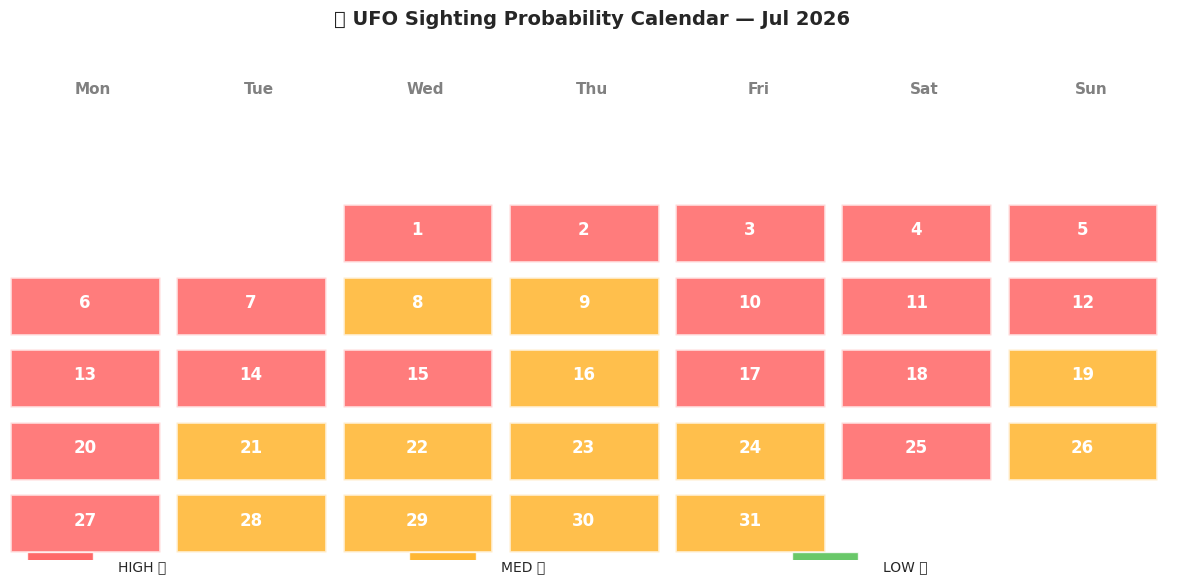

In [23]:
# ===== Visualization: Day Probability Calendar for July 2026 =====

import calendar

def plot_month_calendar(target_month, target_year=2026):
    df_days = predict_ufo_for_month(target_month, target_year)
    m_name = month_names[target_month - 1]
    num_days = calendar.monthrange(target_year, target_month)[1]
    first_weekday = calendar.monthrange(target_year, target_month)[0]  # 0=Mon

    color_map = {'high': '#FF4444', 'medium': '#FFA500', 'low': '#44BB44'}
    label_map = {'high': 'HIGH 🔴', 'medium': 'MED 🟡', 'low': 'LOW 🟢'}

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.set_xlim(0, 7)
    ax.set_ylim(0, 7)
    ax.axis('off')
    ax.set_title(f'🛸 UFO Sighting Probability Calendar — {m_name} {target_year}',
                 fontsize=14, fontweight='bold', pad=20)

    weekdays = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
    for i, wd in enumerate(weekdays):
        ax.text(i + 0.5, 6.5, wd, ha='center', va='center',
                fontweight='bold', fontsize=11, color='gray')

    day_proba = dict(zip(df_days['day'], df_days['probability_level']))

    col = first_weekday
    row = 5

    for day in range(1, num_days + 1):
        level = day_proba.get(day, 'low')
        color = color_map[level]
        rect = plt.Rectangle((col, row - 0.9), 0.9, 0.8,
                              facecolor=color, alpha=0.7, edgecolor='white', linewidth=2)
        ax.add_patch(rect)
        ax.text(col + 0.45, row - 0.45, str(day),
                ha='center', va='center', fontsize=12, fontweight='bold', color='white')
        col += 1
        if col == 7:
            col = 0
            row -= 1

    # Legend
    for i, (level, label) in enumerate(label_map.items()):
        rect = plt.Rectangle((0.1 + i*2.3, -0.3), 0.4, 0.4,
                              facecolor=color_map[level], alpha=0.8)
        ax.add_patch(rect)
        ax.text(0.65 + i*2.3, -0.1, label, va='center', fontsize=10)

    plt.tight_layout()
    plt.savefig(f'calendar_{m_name.lower()}_{target_year}.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_month_calendar(7, 2026)


  🛸 UFO Prediction: Jan 2026  

📊 จำนวนที่ทำนาย: 521 sightings ในเดือน Jan 2026
   (ช่วงความไม่แน่นอน: 442–599 sightings)

🔮 รูปร่าง UFO ที่น่าจะพบในเดือน Jan:
   อันดับ 1: 💡 LIGHT        (32.4% probability)
   อันดับ 2: ❔ UNKNOWN      (15.6% probability)
   อันดับ 3: 🔺 TRIANGLE     (11.9% probability)

📅 วันที่มีแนวโน้มพบ UFO สูงในเดือน Jan 2026:
  🔴 HIGH   probability days: [15]
  🟡 MEDIUM probability days: [1, 3, 4, 5, 6, 7, 8, 10, 11, 12, 13, 14, 16, 18, 20, 24, 25, 26]
  🟢 LOW    probability days: [2, 9, 17, 19, 21, 22, 23, 27, 28, 29, 30, 31]


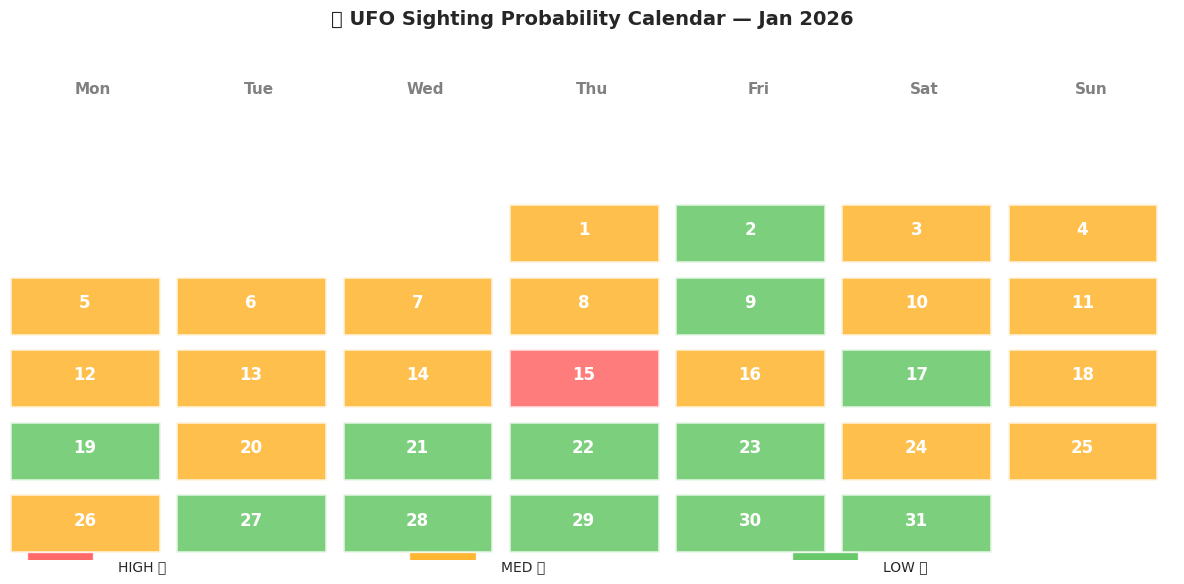

In [24]:
plot_month_calendar(1, 2026)

In [25]:
# ===== บันทึกโมเดลทั้งหมด =====

joblib.dump(best_model_A, 'model_monthly_count.pkl')
joblib.dump(best_model_B, 'model_shape_classifier.pkl')
joblib.dump(pipeline_C, 'model_day_probability.pkl')
joblib.dump(le, 'label_encoder_shape.pkl')
joblib.dump(le_C, 'label_encoder_day.pkl')
joblib.dump(df_pred_2026, 'predictions_2026.pkl')

print('✅ Models saved:')
print('  - model_monthly_count.pkl    (Model A: Monthly Regression)')
print('  - model_shape_classifier.pkl (Model B: Shape Classification)')
print('  - model_day_probability.pkl  (Model C: Day Probability)')
print('  - label_encoder_shape.pkl')
print('  - label_encoder_day.pkl')
print('  - predictions_2026.pkl')

✅ Models saved:
  - model_monthly_count.pkl    (Model A: Monthly Regression)
  - model_shape_classifier.pkl (Model B: Shape Classification)
  - model_day_probability.pkl  (Model C: Day Probability)
  - label_encoder_shape.pkl
  - label_encoder_day.pkl
  - predictions_2026.pkl


---
## Summary — ผลลัพธ์โดยรวม

| โมเดล | เป้าหมาย | Algorithm | Metric | ผล |
|-------|----------|-----------|--------|----|  
| Model A | Monthly count | Random Forest Regressor | R² | ดูใน output |
| Model B | Shape classification | Random Forest Classifier | F1-weighted | ดูใน output |
| Model C | Day probability | Gradient Boosting Classifier | Accuracy | ดูใน output |

### สิ่งที่เรียนรู้
1. **Temporal pattern ชัดเจน** — เดือน Summer (มิถุนายน-สิงหาคม) มีการพบ UFO สูงกว่าช่วงอื่นอย่างสม่ำเสมอ  
2. **Class imbalance ส่งผลต่อการเลือก metric** — การใช้ F1-weighted สำหรับ shape classification ดีกว่า accuracy  
3. **Random Forest ชนะ SVM บน tabular data** — เพราะไม่ต้องการ linear separability  
4. **Lag features สำคัญมากสำหรับ time series** — count_lag12 (same month last year) เป็น feature ที่มีความสำคัญสูง  

### สิ่งที่จะพัฒนาต่อ
- เพิ่ม external features เช่น lunar phase, weather data  
- ลอง LSTM/Transformer สำหรับ time series prediction  
- เพิ่มข้อมูลจากประเทศอื่นนอกจาก US  
- Deploy บน Streamlit Community Cloud พร้อม feature importance interactive chart